# 02 · AlphaMissense — the one REAL genome-wide missense predictor

**Who this is for:** a bench scientist meeting computational variant-effect
prediction for the first time. No prior coding or ML background assumed.

---

### What is AlphaMissense?

**AlphaMissense** (Cheng *et al.*, *Science* 2023, PMID **37733863**, from Google
DeepMind) is a machine-learning model that predicts, for **every possible
missense change** in the human proteome, how likely that amino-acid substitution
is to be damaging. A *missense* variant is a single-DNA-letter change that swaps
one amino acid for another (e.g. the CFTR change **p.Gly551Asp**, written
`G551D`: glycine → aspartate at position 551).

AlphaMissense is built on top of **AlphaFold**, DeepMind's protein-structure
predictor. Intuitively: if a mutation would break a protein's folded structure or
land on a position that evolution has kept unchanged for hundreds of millions of
years, it is more likely to be harmful.

### The one thing to remember: it is *unsupervised* w.r.t. clinical labels

This is the single most important fact for this whole toolkit.

AlphaMissense was **NOT trained on ClinVar** "pathogenic"/"benign" clinical
labels. It learned from:

- **protein sequences** across many species (evolutionary conservation), and
- **protein structure** (via AlphaFold),
- with only a *weak* calibration step against how common variants are in human
  populations (common ≈ probably tolerated).

It never saw a doctor's or lab's verdict of "this variant causes disease."

**Why does that matter?** Later in this toolkit (notebook **08**) we will *test*
predictors by comparing them to ClinVar's clinical verdicts. If a predictor had
been *trained* on ClinVar, that comparison would be **circular** — like grading a
student with the exact answer key they memorized. Because AlphaMissense never
saw those labels, comparing it to ClinVar is a **fair, non-circular** test. That
makes it the strongest, cleanest real dataset we have here.


In [1]:
import sys, pathlib
# `toolkit` is THIS repo's toolkit.py (one directory up) — NOT a pip
# package and nothing to do with gnomAD. The line below puts the repo
# root on sys.path so `import toolkit` resolves to ../toolkit.py.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
# %matplotlib inline is a Jupyter magic: it draws matplotlib plots inline below the cell
%matplotlib inline

## 1 · What does the AlphaMissense score mean?

Every variant gets one number called **`am_pathogenicity`** (we rename it
`am_score`), a probability-like value between **0 and 1**:

- **near 0** → predicted **benign** (harmless)
- **near 1** → predicted **pathogenic** (damaging)

AlphaMissense also ships its **own calibrated class boundaries** — it doesn't
just hand you a raw number, it tells you where *it* draws the lines:

| Score range        | AlphaMissense class   |
|--------------------|-----------------------|
| **≥ 0.564**        | `likely_pathogenic`   |
| **0.340 – 0.564**  | `ambiguous`           |
| **≤ 0.340**        | `likely_benign`       |

These two cut-points (**0.340** and **0.564**) are **AlphaMissense's own**
choices, picked by its authors so that the classes match observed rates of
pathogenic vs. benign variation. They are *not* numbers we invented. Our toolkit
stores them so we can re-use the exact same lines:


In [2]:
# AlphaMissense's own calibrated class cut-points, stored in the toolkit:
tk.THRESHOLDS['am']

{'path': 0.564, 'benign': 0.34}

## 2 · Load the REAL AlphaMissense scores

`tk.load_alphamissense()` reads the AlphaMissense scores for CFTR. These were
extracted from DeepMind's genome-wide release (`AlphaMissense_hg38.tsv.gz`,
filtered to CFTR's UniProt ID **P13569**).

The `source` column says **`REAL`** for every row — this is genuine published
model output, not a placeholder or a simulation. Let's look at the first rows.

> **How this data is fetched.** `load_alphamissense()` reads a cached extract that `fetch_scores.py::fetch_alphamissense` built by downloading the AlphaMissense amino-acid-substitutions file (`AlphaMissense_aa_substitutions.tsv.gz`, ~0.6 GB) from Google's `dm_alphamissense` **GCS bucket** and filtering to CFTR (**UniProt P13569**). It is a **bulk file download, not a live API**; pinned in `data_manifest.json`.

In [3]:
am = tk.load_alphamissense()
am.head()

,protein_variant,am_score,am_class,source
6933,S1058R,0.9985,likely_pathogenic,REAL
7534,S1150R,0.9985,likely_pathogenic,REAL
1309,W202R,0.9980,likely_pathogenic,REAL
6812,L1040P,0.9977,likely_pathogenic,REAL
7083,L1082P,0.9977,likely_pathogenic,REAL


### Genome-wide means *every possible* missense — not just observed ones

Notice how **many** rows there are:


In [4]:
print(f"AlphaMissense rows for CFTR : {len(am):,}")
print(f"All from source == 'REAL'   : {(am['source'] == 'REAL').all()}")
print(f"Unique protein variants     : {am['protein_variant'].nunique():,}")

AlphaMissense rows for CFTR : 8,597
All from source == 'REAL'   : True
Unique protein variants     : 8,597


That's several **thousand** variants. Here's the key idea: AlphaMissense scores
**every amino-acid substitution the protein could theoretically have**, whether
or not anyone has ever observed it in a real person. CFTR is 1,480 amino acids
long, and each position can mutate to 19 other amino acids, so there are
thousands of possible missense changes — and AlphaMissense has a prediction for
essentially all of them. That's what **"genome-wide"** (or here, "saturation")
means, and it's why AlphaMissense can score a brand-new variant a clinic has
never seen before.

Now let's see how the variants split across the three classes:

> **Which AlphaFold?** AlphaMissense (Cheng et al. 2023, *Science*, PMID 37733863) is built on **AlphaFold2**-derived protein-structure representations — it **predates AlphaFold3 (2024)** and does *not* use it.

In [5]:
am['am_class'].value_counts()

am_class
likely_benign        4868
likely_pathogenic    2629
ambiguous            1100
Name: count, dtype: int64

Most possible CFTR missense changes are predicted **`likely_benign`** — which
fits biology: proteins tolerate many substitutions, and only a minority of
positions are truly critical. A substantial chunk is predicted
`likely_pathogenic`, and a smaller `ambiguous` middle sits in the grey zone
between the two cut-points.


## 3 · The distribution of scores — a histogram

Let's plot all the `am_score` values. We draw two vertical lines at the class
boundaries **0.340** (benign cut) and **0.564** (pathogenic cut) so you can see
where AlphaMissense splits the population.


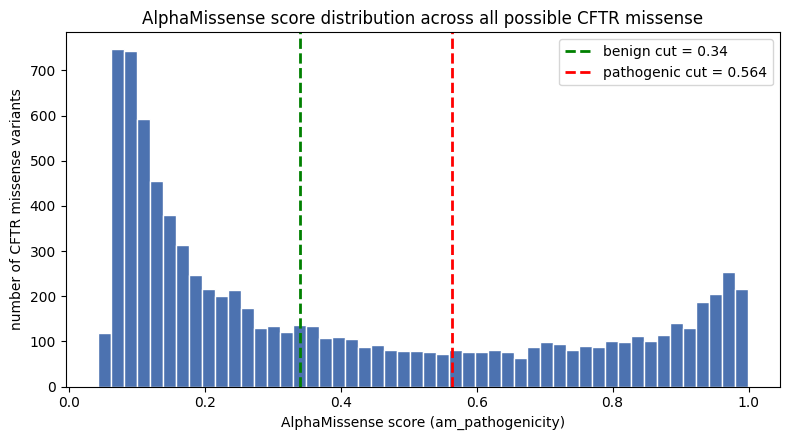

In [6]:
import matplotlib.pyplot as plt

t = tk.THRESHOLDS['am']
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(am['am_score'], bins=50, color='#4C72B0', edgecolor='white')
ax.axvline(t['benign'], color='green', linestyle='--', linewidth=2,
           label=f"benign cut = {t['benign']}")
ax.axvline(t['path'],   color='red',   linestyle='--', linewidth=2,
           label=f"pathogenic cut = {t['path']}")
ax.set_xlabel('AlphaMissense score (am_pathogenicity)')
ax.set_ylabel('number of CFTR missense variants')
ax.set_title('AlphaMissense score distribution across all possible CFTR missense')
ax.legend()
plt.tight_layout()
plt.show()

**Reading the histogram — bimodality.** The distribution is **bimodal**: there
are two "humps," one piled up near **0** (confidently benign) and another near
**1** (confidently pathogenic), with a thinner valley in the middle. This is a
good sign — it means the model is often *decisive* rather than sitting on the
fence. The middle `ambiguous` band (between the two dashed lines) is where the
model is genuinely uncertain, and those are the variants that most need
orthogonal evidence (family data, functional assays, other predictors).


## 4 · Turning a score into a call — `tk.call_from_score`

The toolkit has one helper, `tk.call_from_score(score, 'am')`, that applies the
`'am'` cut-points from the table above and returns a plain word. We keep this
logic in **one place** so every notebook labels variants the same way. Let's feed
it three example scores to see all three outcomes:


In [7]:
examples = [0.9, 0.5, 0.1]
for s in examples:
    print(f"score {s:>4}  ->  {tk.call_from_score(s, 'am')}")

score  0.9  ->  pathogenic
score  0.5  ->  uncertain
score  0.1  ->  benign


- **0.9** is above 0.564 → **pathogenic**
- **0.5** falls in the 0.340–0.564 grey zone → **uncertain** (AlphaMissense's
  `ambiguous`)
- **0.1** is below 0.340 → **benign**

This is exactly the 3-class logic from Section 1, now applied programmatically.


## 5 · Which *observed* variants does AlphaMissense flag?

AlphaMissense scores every *possible* variant, but clinicians care most about the
ones that actually **occur in people**. **gnomAD** (the Genome Aggregation
Database) is a catalogue of variants seen across ~800,000 individuals. By
**joining** AlphaMissense to gnomAD on the shared `protein_variant` column, we
keep only the AlphaMissense predictions for variants that have really been
observed.

We use an **inner merge**: a row survives only if the variant is present in
*both* tables.


In [8]:
gnomad = tk.load_gnomad_missense()
print(f"gnomAD-observed CFTR missense variants : {len(gnomad):,}")

merged = am.merge(
    gnomad[['protein_variant', 'gnomad_af', 'source']],
    on='protein_variant',
    how='inner',
    suffixes=('_am', '_gnomad'),
)
print(f"...of which have an AlphaMissense score : {len(merged):,}")

gnomAD-observed CFTR missense variants : 2,466
...of which have an AlphaMissense score : 2,430


So a large fraction of real, observed CFTR missense variants have an
AlphaMissense prediction available. (A handful of gnomAD variants may not match —
usually formatting edge-cases in the amino-acid notation.)

Now the interesting part: of the variants **actually observed in humans**, which
ones does AlphaMissense predict to be **most pathogenic**? We sort by `am_score`
and show the top 10. We keep the `source` columns visible so you can confirm both
datasets are `REAL`.


In [9]:
top10 = (merged
         .sort_values('am_score', ascending=False)
         .head(10)
         [['protein_variant', 'am_score', 'am_class',
           'gnomad_af', 'source_am', 'source_gnomad']]
         .reset_index(drop=True))
top10

,protein_variant,am_score,am_class,gnomad_af,source_am,source_gnomad
0,S1058R,0.9985,likely_pathogenic,6.846530e-07,REAL,REAL
1,S1150R,0.9985,likely_pathogenic,0.000000e+00,REAL,REAL
2,L1040P,0.9977,likely_pathogenic,6.843156e-07,REAL,REAL
3,L1082P,0.9977,likely_pathogenic,6.843156e-07,REAL,REAL
4,W57R,0.9970,likely_pathogenic,3.456557e-06,REAL,REAL
5,Y569D,0.9964,likely_pathogenic,4.202694e-05,REAL,REAL
6,W496R,0.9959,likely_pathogenic,0.000000e+00,REAL,REAL
7,A559E,0.9958,likely_pathogenic,0.000000e+00,REAL,REAL
8,Y563D,0.9955,likely_pathogenic,6.892093e-07,REAL,REAL
9,C524R,0.9954,likely_pathogenic,1.971790e-05,REAL,REAL


These are **real, human-observed** CFTR missense variants that AlphaMissense
ranks as most likely damaging. Notice their **`gnomad_af`** (allele frequency)
values are tiny — these variants are **rare**, which is consistent with a damaging
effect (a variant that broke an essential protein would be selected against and
stay rare). That agreement between an *independent* frequency signal and the
prediction is reassuring, though — see the next section — it is still not proof.


## 6 · Important cautions

AlphaMissense is powerful, but keep these limits in mind:

1. **A prediction is not proof.** A high `am_score` is a *hypothesis* that a
   variant is damaging — strong supporting evidence (ACMG code **PP3**; Richards et al. 2015, PMID 25741868), never a
   diagnosis on its own. Clinical classification also needs family segregation,
   functional assays, and case data.
2. **It is a single tool.** One model can be systematically wrong for a whole
   class of variants. Later notebooks add other predictors precisely so we can
   look for *agreement*, which is more trustworthy than any one score.
3. **Thresholds are a simplification.** The 0.340 / 0.564 cut-points turn a smooth
   probability into hard boxes. A variant scoring **0.57** and one scoring
   **0.95** are both "pathogenic," but they are *not* equally certain — always
   look at the underlying number, not just the label.
4. **Missense only.** AlphaMissense says nothing about splice, frameshift,
   stop-gain, or non-coding variants (including CFTR's famous poly-T / TG splice
   region). Those need different tools.


## 7 · Key takeaways

- **AlphaMissense** (Cheng *et al.* 2023, DeepMind) predicts the damage of every
  possible missense variant, on a **0–1** scale, by adapting **AlphaFold**.
- It is **unsupervised with respect to clinical labels** — trained on protein
  sequence + structure + weak population-frequency calibration, **not** on
  ClinVar. This is what makes it a **fair, non-circular** benchmark against
  clinical data (revisited in **notebook 12**).
- Its **own calibrated cut-points** are **≥ 0.564** (`likely_pathogenic`) and
  **≤ 0.340** (`likely_benign`); `tk.call_from_score(score, 'am')` applies them.
- The score distribution is **bimodal** — the model is usually confident, with a
  small ambiguous middle band.
- It is **genome-wide / saturation**: it can score even never-before-seen
  variants. Joined to **gnomAD**, we saw the most-pathogenic *observed* CFTR
  missense variants are also **rare**, an encouraging independent cross-check.
- It remains a **single computational prediction**: supporting evidence, not
  proof, and blind to non-missense variation.
- This is the **strongest, fully REAL, genome-wide** dataset in the toolkit.
